You are tasked with creating a photo stylization program using OpenCV.
Your program should take in a single image and produce an artistic output where the main subject
is highlighted and the background is stylized.
Requirements:
1. Input & Output
 - The program should read an image file.
 - It should save and display the final result.
2. Processing Steps
 Your solution should include the following:
 - Image Enhancement: Improve global contrast using CLAHE.
 - Mask Creation: Automatically identify and isolate the main subject by generating a mask
 (largest contour or foreground).
 - Stylization:
 * Apply edge-preserving smoothing (bilateral filter) on the subject.
 * Desaturate and slightly blur the background.
 * Overlay stylized edges (from Canny edge detection) as an artistic outline.
 - Blending: Combine subject and background smoothly using the mask.
3. Final Output
 - Display a montage showing:
 * Original image
 * Subject mask preview
 * Enhanced image
 * Final stylized result
Constraints:
- You must use only OpenCV and NumPy.
- No camera input or pretrained models (e.g., face detection).
- The solution should run in under one minute per image.
Deliverables:
- A Python script named selective_stylizer.py.
- When run, it should generate and display a result image saved as stylized_result.jpg.
Example (expected effect):
- The background should appear muted and blurred.
- The subject should appear smooth and vibrant.
- Artistic edge outlines should highlight details.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

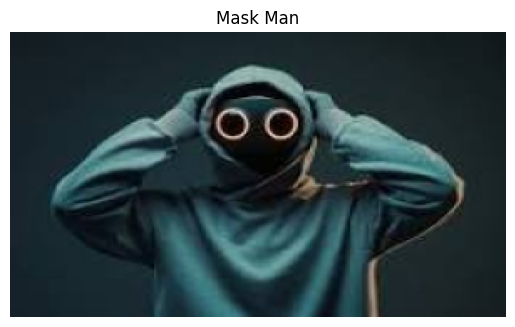

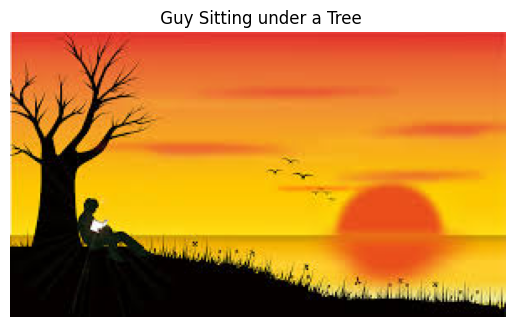

True

In [10]:
img_path1='/content/maskman.jpg'
img_path2='/content/scenary.jpg'
img1=cv2.imread(img_path1)
img2=cv2.imread(img_path2)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
height, width = img2.shape[:2]
img1 = cv2.resize(img1,(width,height),interpolation=cv2.INTER_AREA)
plt.imshow(img1)
plt.title('Mask Man')
plt.axis('off')
plt.show()
print()
print()

img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
plt.imshow(img2)
plt.title(' Guy Sitting under a Tree')
plt.axis('off')
plt.show()
print()
cv2.imwrite('img1.jpg', img1)
cv2.imwrite('img2.jpg',img2)

In [18]:
# image enhancement using CLAHE
img1=cv2.imread(img_path1,0)
img2=cv2.imread(img_path2,0)
equ = cv2.equalizeHist(img1)
print("--"*10 + "\n IMG 1   \n"+ "--"*10)
print(img1)
print("--"*10 + "\n EQU   \n"+ "--"*10)
print(equ)
print("--"*10)
equ1 = cv2.equalizeHist(img2)
print("--"*10 + "\n IMG 2   \n"+ "--"*10)
print(img2)
print("--"*10 + "\n EQU   \n"+ "--"*10)
print(equ1)

--------------------
 IMG 1   
--------------------
[[26 26 26 ... 21 22 22]
 [26 26 26 ... 21 22 22]
 [26 26 26 ... 22 22 22]
 ...
 [30 30 30 ... 29 28 28]
 [30 30 30 ... 29 28 28]
 [30 30 30 ... 29 28 28]]
--------------------
 EQU   
--------------------
[[33 33 33 ... 23 24 24]
 [33 33 33 ... 23 24 24]
 [33 33 33 ... 24 24 24]
 ...
 [57 57 57 ... 48 42 42]
 [57 57 57 ... 48 42 42]
 [57 57 57 ... 48 42 42]]
--------------------
--------------------
 IMG 2   
--------------------
[[198 104 108 ... 110 116 125]
 [193  99 104 ...  97 103 112]
 [191  98 102 ...  97 103 112]
 ...
 [  1   1   1 ...   0   0  22]
 [  1   1   1 ...   0   2  16]
 [  1   1   1 ...   0   2  16]]
--------------------
 EQU   
--------------------
[[237  51  53 ...  55  61  77]
 [222  48  51 ...  48  50  57]
 [214  48  50 ...  48  50  57]
 ...
 [ 22  22  22 ...   0   0  42]
 [ 22  22  22 ...   0  26  41]
 [ 22  22  22 ...   0  26  41]]


(array([ 420.,  352.,  130.,  482.,  197.,  419.,  213.,  336.,  166.,
         381.,  402.,  213.,  394.,    0.,  466.,    0.,  658.,    0.,
         740.,    0.,    0.,    0., 1122.,    0.,    0.,    0.,    0.,
        1669.,    0.,    0.,    0., 1097.,    0.,    0., 1127.,    0.,
           0.,    0.,    0.,    0., 1500.,    0.,    0.,    0.,    0.,
           0.,    0., 2246.,    0.,    0.,    0.,    0., 1630.,    0.,
           0.,    0.,    0.,    0.,    0.,    0., 2450.,    0.,    0.,
        1053.,    0.,    0.,  795.,  426.,  308.,  265.,  271.,  290.,
         344.,  258.,  482.,  262.,  360.,  212.,  418.,  226.,  396.,
         382.,  237.,  315.,  229.,  384.,  274.,  316.,  258.,  408.,
         329.,  270.,  347.,  242.,  380.,  221.,  398.,  233.,  360.,
         321.]),
 array([  0.  ,   2.55,   5.1 ,   7.65,  10.2 ,  12.75,  15.3 ,  17.85,
         20.4 ,  22.95,  25.5 ,  28.05,  30.6 ,  33.15,  35.7 ,  38.25,
         40.8 ,  43.35,  45.9 ,  48.45,  51.  ,  53.55,  5

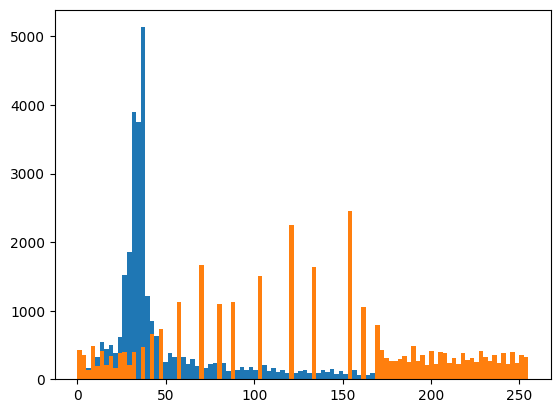

In [26]:
plt.hist(img1.flat, bins=100, range=(0, 255))
plt.hist(equ.flat, bins=100, range=(0, 255))



(array([145., 147.,  84., 123.,  69., 146.,  64., 108.,  56., 115., 103.,
         59., 122.,  52., 130.,  52., 125.,  57., 135.,  65., 115., 110.,
         53., 106.,  76., 110.,  55., 104.,  55., 136., 116.,  57., 127.,
         50.,  89.,  60., 122.,  54., 114.,  57., 113., 104.,  61., 101.,
         48., 117.,  67., 133.,  63., 112., 114.,  43., 100.,  61., 113.,
         51.,  94.,  53., 100.,  38.,  87.,  84.,  41.,  87.,  53.,  75.,
         46.,  78.,  41.,  87.,  78.,  45.,  99.,  42.,  67.,  40.,  68.,
         37.,  64.,  22.,  64.,  62.,  22.,  47.,  19.,  66.,  20.,  39.,
         11.,  33.,  42.,  24.,  32.,  16.,  25.,   8.,  19.,  10.,   8.,
         10.]),
 array([100.  , 101.55, 103.1 , 104.65, 106.2 , 107.75, 109.3 , 110.85,
        112.4 , 113.95, 115.5 , 117.05, 118.6 , 120.15, 121.7 , 123.25,
        124.8 , 126.35, 127.9 , 129.45, 131.  , 132.55, 134.1 , 135.65,
        137.2 , 138.75, 140.3 , 141.85, 143.4 , 144.95, 146.5 , 148.05,
        149.6 , 151.15, 152.7 

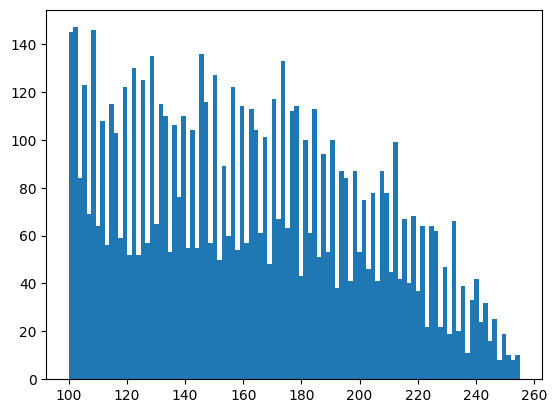

In [27]:
clahe = cv2.createCLAHE(clipLimit =2.0, tileGridSize=(8,8))
cl_img = clahe.apply(img1)
plt.hist(cl_img.flat, bins=100, range=(100, 255))

(array([1519.,    0.,    0.,    0.,    0.,    0.,    0.,    0., 4138.,
           0.,  796.,  739.,  524.,  398.,  683.,  449.,  587.,  389.,
         493.,  451.,  566.,  423.,  447.,  647.,  234.,  271.,    0.,
        1340.,  355.,  588.,  528.,  476.,  276.,  654.,  354.,  413.,
         827.,  203.,  451.,  424.,  833.,  382.,  450.,  455.,  488.,
         739.,  375.,  321.,  314.,  691.,  802.,  261.,  575.,  325.,
         403.,  440.,  776.,  452.,    0.,  685.,  697.,  565.,  518.,
         453.,  537.,  447.,    0.,  979.,    0.,  823.,  644.,  343.,
         718.,    0.,  673.,  437.,  429.,  474.,  910.,    0.,  842.,
         684.,  405.,  552.,    0.,  448.,    0.,  991.,  648.,  628.,
         373.,  611.,  622.,    0.,  850.,  480.,  607.,  211.,  784.,
         527.]),
 array([  0.  ,   2.55,   5.1 ,   7.65,  10.2 ,  12.75,  15.3 ,  17.85,
         20.4 ,  22.95,  25.5 ,  28.05,  30.6 ,  33.15,  35.7 ,  38.25,
         40.8 ,  43.35,  45.9 ,  48.45,  51.  ,  53.55,  5

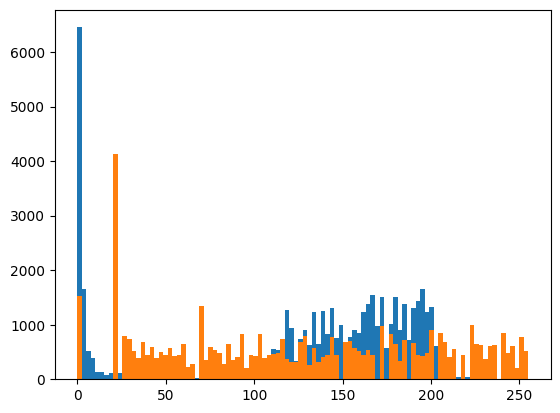

In [21]:
plt.hist(img2.flat, bins=100, range=(0, 255))
plt.hist(equ1.flat, bins=100, range=(0, 255))

(array([145., 147.,  84., 123.,  69., 146.,  64., 108.,  56., 115., 103.,
         59., 122.,  52., 130.,  52., 125.,  57., 135.,  65., 115., 110.,
         53., 106.,  76., 110.,  55., 104.,  55., 136., 116.,  57., 127.,
         50.,  89.,  60., 122.,  54., 114.,  57., 113., 104.,  61., 101.,
         48., 117.,  67., 133.,  63., 112., 114.,  43., 100.,  61., 113.,
         51.,  94.,  53., 100.,  38.,  87.,  84.,  41.,  87.,  53.,  75.,
         46.,  78.,  41.,  87.,  78.,  45.,  99.,  42.,  67.,  40.,  68.,
         37.,  64.,  22.,  64.,  62.,  22.,  47.,  19.,  66.,  20.,  39.,
         11.,  33.,  42.,  24.,  32.,  16.,  25.,   8.,  19.,  10.,   8.,
         10.]),
 array([100.  , 101.55, 103.1 , 104.65, 106.2 , 107.75, 109.3 , 110.85,
        112.4 , 113.95, 115.5 , 117.05, 118.6 , 120.15, 121.7 , 123.25,
        124.8 , 126.35, 127.9 , 129.45, 131.  , 132.55, 134.1 , 135.65,
        137.2 , 138.75, 140.3 , 141.85, 143.4 , 144.95, 146.5 , 148.05,
        149.6 , 151.15, 152.7 

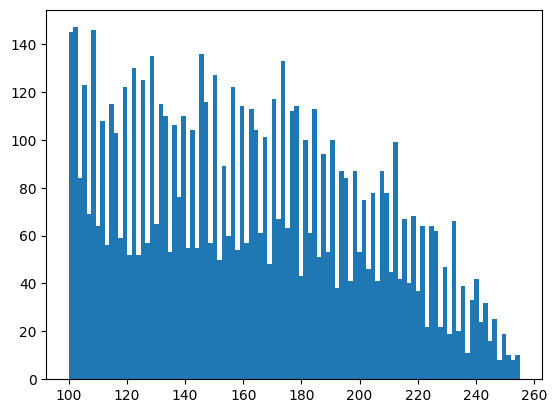

In [28]:
clahe = cv2.createCLAHE(clipLimit =2.0, tileGridSize=(8,8))
cl_img1 = clahe.apply(img2)
plt.hist(cl_img.flat, bins=100, range=(100, 255))

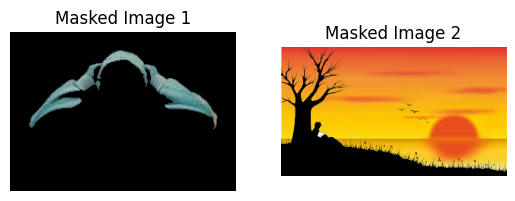

In [31]:
#Image MAsking with largest Contour
def create_largest_contour_mask(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("Error: No contours found.")
        return None

    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    return masked_img, mask
a = create_largest_contour_mask(img_path1)
b = create_largest_contour_mask(img_path2)

# Display the masked images
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(a[0], cv2.COLOR_BGR2RGB))
plt.title('Masked Image 1')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(b[0], cv2.COLOR_BGR2RGB))
plt.title('Masked Image 2')
plt.axis('off')

plt.show()

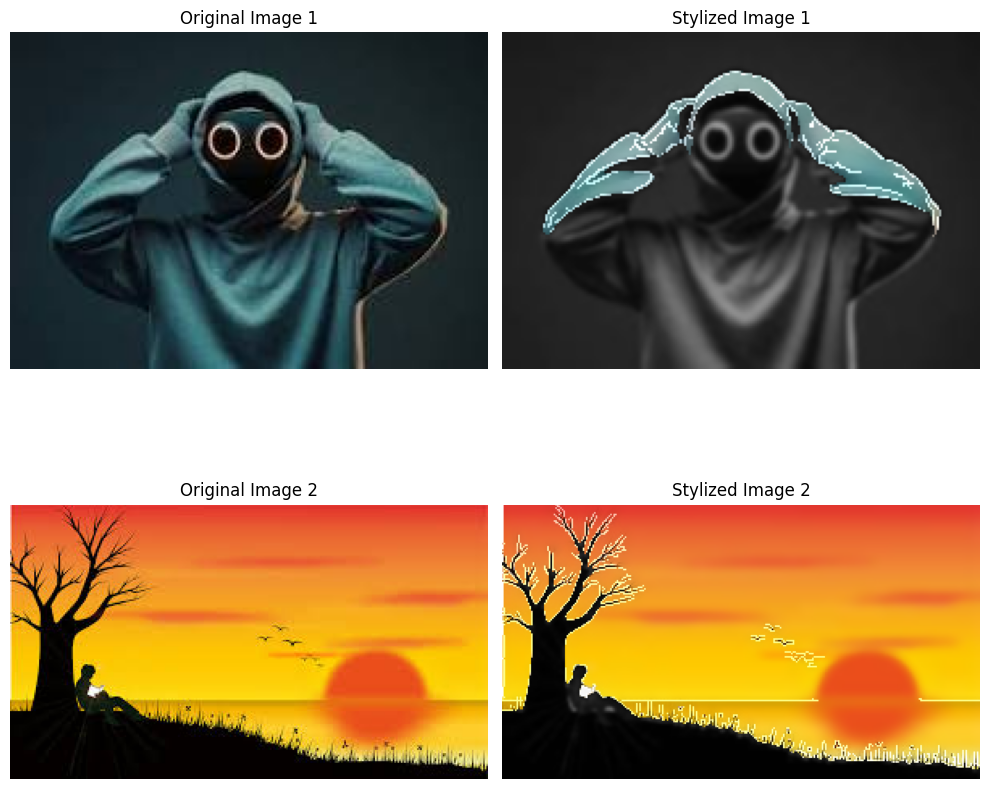

Stylized image saved as stylized_result.jpg


In [46]:
# Stylization and Blending

def stylize_and_blend(original_img, mask):
    # Ensure original_img is BGR for processing
    if len(original_img.shape) == 3 and original_img.shape[2] == 3:
        img_bgr = original_img.copy()
    else:
        img_bgr = cv2.cvtColor(original_img, cv2.COLOR_GRAY2BGR)


    # 1. Subject Stylization (Bilateral Filter)
    subject_smooth = cv2.bilateralFilter(img_bgr, 9, 75, 75)

    # 2. Background Stylization (Desaturation and Blur)
    background = cv2.bitwise_and(img_bgr, img_bgr, mask=cv2.bitwise_not(mask))
    background_gray = cv2.cvtColor(background, cv2.COLOR_BGR2GRAY)
    background_blurred = cv2.GaussianBlur(background_gray, (5, 5), 0)
    background_stylized = cv2.cvtColor(background_blurred, cv2.COLOR_GRAY2BGR) # Convert back to BGR for blending

    # 3. Stylized Edges (Canny Edge Detection)
    edges = cv2.Canny(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), 100, 200)
    edges_color = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR) # Convert edges to color

    # 4. Blending
    # Subject is the smoothed image where the mask is white
    subject_part = cv2.bitwise_and(subject_smooth, subject_smooth, mask=mask)
    # Background is the stylized background where the mask is black
    background_part = cv2.bitwise_and(background_stylized, background_stylized, mask=cv2.bitwise_not(mask))

    # Combine subject and background
    blended_img = cv2.add(subject_part, background_part)

    # Overlay edges - use the mask to only add edges where the subject is
    edge_overlay = cv2.bitwise_and(edges_color, edges_color, mask=mask)
    final_result = cv2.addWeighted(blended_img, 1, edge_overlay, 0.5, 0) # Adjust weight for edge visibility

    return final_result

# Process and display both images
img_paths = [img_path1, img_path2]
masks = [a[1], b[1]] # Assuming 'a' and 'b' contain (masked_img, mask) from the previous step

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for i in range(2):
    original_img = cv2.imread(img_paths[i])
    if original_img is None:
        print(f"Error: Could not load original image {img_paths[i]}.")
        continue

    mask = masks[i]
    stylized_img = stylize_and_blend(original_img, mask)

    axs[i, 0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    axs[i, 0].set_title(f'Original Image {i+1}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(cv2.cvtColor(stylized_img, cv2.COLOR_BGR2RGB))
    axs[i, 1].set_title(f'Stylized Image {i+1}')
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

# Save the stylized result for the first image as required
cv2.imwrite('stylized_result.jpg', cv2.cvtColor(stylized_img1, cv2.COLOR_BGR2RGB))
print("Stylized image saved as stylized_result.jpg")